<div style="display: flex; background-color: RGB(0,102,204);" >
<h1 style="margin: auto; padding: 30px; ">Analyse des ventes de la librairie Lapage</h1>
</div>

<div style="display: flex; background-color: RGB(51,153,255);" >
<h1 style="margin: auto; padding: 30px; ">📊 Etape 1 - Import des librairies et des fichiers</h1>
</div>

In [1]:
#Importation des différentes librairies
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import shapiro
from scipy.stats import kruskal
from scipy.stats import normaltest

In [2]:
#Import des trois fichiers de données
customers = pd.read_csv('customers.csv', sep=";")
products = pd.read_csv('products.csv', sep=";")
transactions = pd.read_csv('transactions.csv', sep=";")

<div style="display: flex; background-color: RGB(51,153,255);" >
<h1 style="margin: auto; padding: 30px; ">📊 Étape 2 - Analyse exploratoire des fichiers et fusion</h1>
</div>


<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">2.1 Le fichier customers</h1>
</div>

In [3]:
#Prise de connaissance des dimensions du data set et des types de données
print("Le nombre de colonnes est de {}".format(len(customers.columns)))
print("Les types de donneés dans chaque colonne sont :\n{}".format(customers.dtypes))
print("Pour chaque colonne, voici le nombre de valeurs :\n{}".format(customers.count()))

Le nombre de colonnes est de 3
Les types de donneés dans chaque colonne sont :
client_id    object
sex          object
birth         int64
dtype: object
Pour chaque colonne, voici le nombre de valeurs :
client_id    8621
sex          8621
birth        8621
dtype: int64


In [4]:
#Calcul de l'âge des clients pour permettre les calculs
current_year = datetime.now().year
customers['age'] = current_year - customers['birth']

#Je supprime la colonne 'birth' devenue inutile
customers.drop(columns='birth', inplace=True)

In [5]:
customers.head(5)

,client_id,sex,age
0,c_4410,f,58
1,c_7839,f,50
2,c_1699,f,41
3,c_5961,f,63
4,c_5320,m,82



<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">2.2 Le fichier products</h1>
</div>

In [6]:
#Prise de connaissance des dimensions du data set et des types de données
print("Le nombre de colonnes est de {}".format(len(products.columns)))
print("Les types de donneés dans chaque colonne sont :\n{}".format(products.dtypes))
print("Pour chaque colonne, voici le nombre de valeurs :\n{}".format(products.count()))

Le nombre de colonnes est de 3
Les types de donneés dans chaque colonne sont :
id_prod     object
price      float64
categ        int64
dtype: object
Pour chaque colonne, voici le nombre de valeurs :
id_prod    3286
price      3286
categ      3286
dtype: int64


In [7]:
#Je renomme les numéros de catégories pour plus de lisibilité
products['categ'] = products['categ'].replace({
    0: 'categ 1',
    1: 'categ 2',
    2: 'categ 3'
})

In [8]:
products.head(5)

,id_prod,price,categ
0,0_1421,19.99,categ 1
1,0_1368,5.13,categ 1
2,0_731,17.99,categ 1
3,1_587,4.99,categ 2
4,0_1507,3.99,categ 1


<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">2.3 Le fichier transactions</h1>
</div>

In [9]:
#Prise de connaissance des dimensions du data set et des types de données
print("Le nombre de colonnes est de {}".format(len(transactions.columns)))
print("Les types de donneés dans chaque colonne sont :\n{}".format(transactions.dtypes))
print("Pour chaque colonne, voici le nombre de valeurs :\n{}".format(transactions.count()))

Le nombre de colonnes est de 4
Les types de donneés dans chaque colonne sont :
id_prod       object
date          object
session_id    object
client_id     object
dtype: object
Pour chaque colonne, voici le nombre de valeurs :
id_prod       687534
date          687534
session_id    687534
client_id     687534
dtype: int64


In [10]:
#Changement de type de donnée de la colonne date
transactions['date'] = pd.to_datetime(transactions['date'], format="%Y-%m-%d %H:%M:%S.%f")

<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">2.4 Fusion des fichiers</h1>
</div>

In [11]:
# Vérification d'un nombre d'id prod dans chaque fichier en amont de la fusion
id_prod_distinct_transactions = transactions['id_prod'].nunique()
id_prod_distinct_products = products['id_prod'].nunique()
print(f"Le nombre d'id_prod distincts dans le fichier transactions est de {id_prod_distinct_transactions}")
print(f"Le nombre d'id_prod distincts dans le fichier products est de {id_prod_distinct_products}")
diff_products_transactions = id_prod_distinct_products - id_prod_distinct_transactions
print(f"Il y a donc {diff_products_transactions} articles qui ne se sont pas vendus sur la période")

Le nombre d'id_prod distincts dans le fichier transactions est de 3265
Le nombre d'id_prod distincts dans le fichier products est de 3286
Il y a donc 21 articles qui ne se sont pas vendus sur la période


In [12]:
#Fusion des df products et transactions
df_merge1 = pd.merge(transactions, products, on="id_prod", how="left")
df_merge1.head(5)


,id_prod,date,session_id,client_id,price,categ
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,categ 1
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,categ 1
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,categ 1
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,categ 1
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,categ 1


In [13]:
#Contrôle du nombre de lignes après la première fusion
print("Pour chaque colonne, voici le nombre de valeurs :\n{}".format(df_merge1.count()))

Pour chaque colonne, voici le nombre de valeurs :
id_prod       687534
date          687534
session_id    687534
client_id     687534
price         687534
categ         687534
dtype: int64


In [14]:
# Vérification d'un nombre de client_id dans chaque fichier en amont de la fusion
print("Le nombre de client_id distincts dans le fichier transactions est de {}".format(transactions['client_id'].nunique()))
print("Le nombre de client_id distincts dans le fichier customers est de {}".format(customers['client_id'].nunique()))
print("Le nombre de client_id distincts dans le fichier df_merge1 est de {}".format(df_merge1['client_id'].nunique()))

Le nombre de client_id distincts dans le fichier transactions est de 8600
Le nombre de client_id distincts dans le fichier customers est de 8621
Le nombre de client_id distincts dans le fichier df_merge1 est de 8600


In [15]:
#Fusion des df df_merge1 et customers
df_merge = pd.merge(df_merge1, customers, on="client_id", how="left")
df_merge.head(5)

,id_prod,date,session_id,client_id,price,categ,sex,age
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,categ 1,f,58
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,categ 1,m,65
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,categ 1,m,37
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,categ 1,f,36
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,categ 1,f,69


In [16]:
#Contrôle du nombre de lignes après la fusion finale
print("Pour chaque colonne, voici le nombre de valeurs :\n{}".format(df_merge.count()))

Pour chaque colonne, voici le nombre de valeurs :
id_prod       687534
date          687534
session_id    687534
client_id     687534
price         687534
categ         687534
sex           687534
age           687534
dtype: int64


In [17]:
# L'analyse des clients a permis de détecter la présence de 4 clients atypiques
clients_CA_total = df_merge.groupby('client_id')['price'].sum().reset_index(name='CA par client').sort_values(by='CA par client', ascending=False)
#Création de la colonne Part du CA total
clients_CA_total['Part du CA total'] = round(clients_CA_total['CA par client']/clients_CA_total['CA par client'].sum()*100,2)
clients_CA_total.head(10)

,client_id,CA par client,Part du CA total
677,c_1609,326039.89,2.71
4388,c_4958,290227.03,2.41
6337,c_6714,153918.60,1.28
2724,c_3454,114110.57,0.95
634,c_1570,5285.82,0.04
2513,c_3263,5276.87,0.04
1268,c_2140,5260.18,0.04
2108,c_2899,5214.05,0.04
7006,c_7319,5155.77,0.04
7715,c_7959,5135.75,0.04


In [18]:
# Calcul de la part du CA représenté par les clients BtoB
client_b_to_b = clients_CA_total.nlargest(4, 'Part du CA total')
print(round(client_b_to_b['Part du CA total'].sum(),1))

7.4


In [19]:
# J'exclue ces clients BtoB pour poursuivre l'analyse
#J'isole les clients pro dans un df
clients_pro_id = ['c_1609', 'c_4958', 'c_6714', 'c_3454']
#Je filtre dans un nouveau df
df_merge_filtre = df_merge[~df_merge['client_id'].isin(clients_pro_id)]
#Contrôle di nombre de lignes
print("Pour chaque colonne, voici le nombre de valeurs :\n{}".format(df_merge_filtre.count()))

Pour chaque colonne, voici le nombre de valeurs :
id_prod       640734
date          640734
session_id    640734
client_id     640734
price         640734
categ         640734
sex           640734
age           640734
dtype: int64


<div style="display: flex; background-color: RGB(51,153,255);" >
<h1 style="margin: auto; padding: 30px; ">📊 Étape 3 - Analyse du CA</h1>
</div>

<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">3.1 CA total et moyen par jour</h1>
</div>

In [20]:
#Calcul du CA par année
# Regroupement par année
CA_total_2021 =  df_merge_filtre[df_merge_filtre['date'].dt.year == 2021]['price'].sum()
CA_total_2022 = df_merge_filtre[df_merge_filtre['date'].dt.year == 2022]['price'].sum()
CA_total_2023 = df_merge_filtre[df_merge_filtre['date'].dt.year == 2023]['price'].sum()
#Création d'un tableau pour présenter les données
ca_par_annee = pd.DataFrame({
    'Année': ['2021', '2022', '2023'],
    'Chiffre d\'affaires (€)': [CA_total_2021, CA_total_2022, CA_total_2023]
})
ca_par_annee['Chiffre d\'affaires (€)'] = ca_par_annee['Chiffre d\'affaires (€)'].round(2)
display(ca_par_annee)

,Année,Chiffre d'affaires (€)
0,2021,4584976.14
1,2022,5655420.93
2,2023,902969.94


In [21]:
# Il apparaît que la comparaison d'une année civile à l'autre n'est pas le plus judicieux, nous allons redéfinir deux périodes
#Découpage pour découper deux périodes du 01/03 au 28/02 (inclus) de chaque année
p1_deb = pd.Timestamp('2021-03-01')
p2_deb = pd.Timestamp('2022-03-01')
p3_deb = pd.Timestamp('2023-03-01')

mask_p1 = (df_merge_filtre['date'] >= p1_deb) & (df_merge_filtre['date'] < p2_deb)
mask_p2 = (df_merge_filtre['date'] >= p2_deb) & (df_merge_filtre['date'] < p3_deb)

#Calcul du CA par période
CA_total_exercice_2021_2022 = df_merge_filtre.loc[mask_p1, 'price'].sum()
CA_total_exercice_2022_2023 = df_merge_filtre.loc[mask_p2, 'price'].sum()
CA_par_periode = pd.DataFrame({
    'Année': ['2021-2022', '2022-2023'],
    'Chiffre d\'affaires (€)': [CA_total_exercice_2021_2022, CA_total_exercice_2022_2023]
})
CA_par_periode.head()

,Année,Chiffre d'affaires (€)
0,2021-2022,5566713.35
1,2022-2023,5576653.66


In [22]:
# Calcul du CA par mois
ca_mensuel = (
    df_merge_filtre
    .groupby(df_merge_filtre['date'].dt.to_period('M'))['price']
    .sum()
    .reset_index()
)

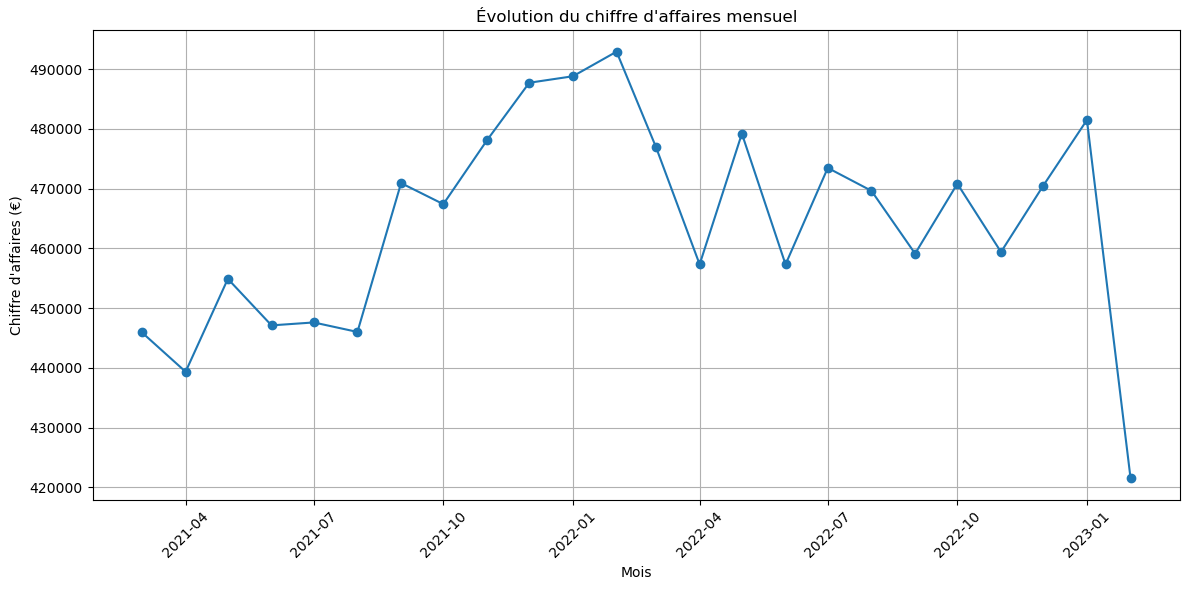

In [23]:
# Représentation graphique de l'évolution du CA

ca_mensuel['date'] = ca_mensuel['date'].dt.to_timestamp()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(ca_mensuel['date'], ca_mensuel['price'], marker='o')
plt.title("Évolution du chiffre d'affaires mensuel")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
#Calcul du CA par jour
ca_journalier = df_merge_filtre.groupby(df_merge_filtre['date'].dt.date)['price'].sum()
ca_journalier.index = pd.to_datetime(ca_journalier.index)
# Moyenne mobile sur 7 jours (par exemple)
ca_journalier_mm7 = ca_journalier.rolling(window=7).mean()
print(ca_journalier_mm7.head(15))

date
2021-03-01             NaN
2021-03-02             NaN
2021-03-03             NaN
2021-03-04             NaN
2021-03-05             NaN
2021-03-06             NaN
2021-03-07    14606.287143
2021-03-08    14466.011429
2021-03-09    14442.135714
2021-03-10    14539.477143
2021-03-11    14537.344286
2021-03-12    14163.058571
2021-03-13    14010.055714
2021-03-14    13975.702857
2021-03-15    14050.137143
Name: price, dtype: float64


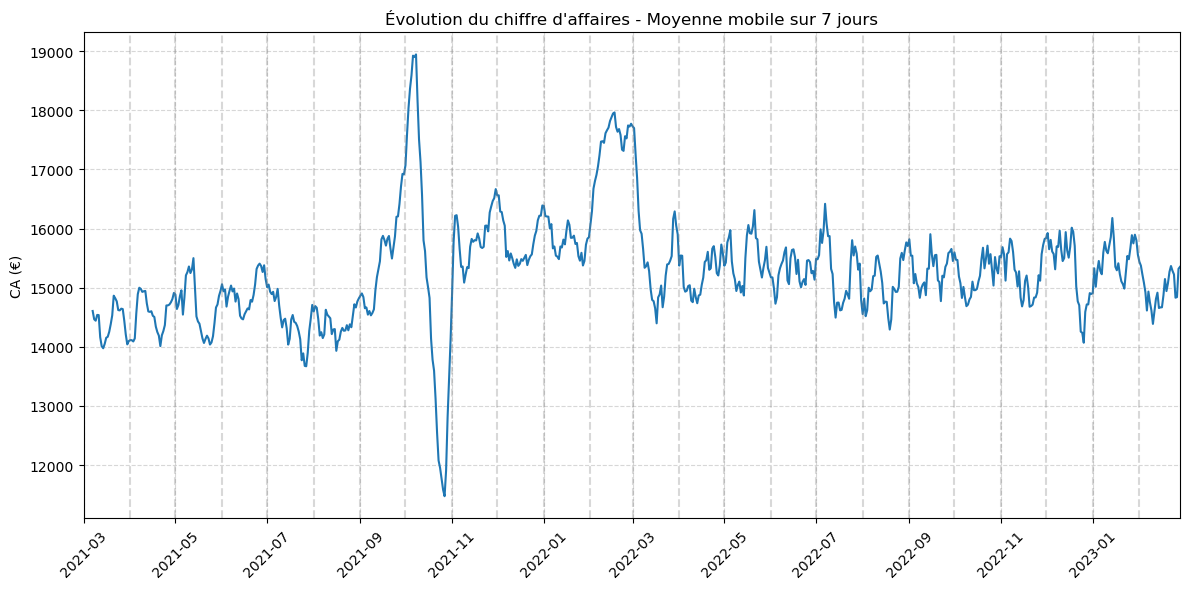

In [25]:
#Représentation graphique de la moyenne mobile hebdomadaire
plt.figure(figsize=(12,6))
plt.plot(ca_journalier_mm7.index, ca_journalier_mm7.values)

plt.title("Évolution du chiffre d'affaires - Moyenne mobile sur 7 jours")
plt.ylabel('CA (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(p1_deb, p3_deb - pd.Timedelta(days=1))

#Boucle sur les débuts de mois
debut_mois = pd.date_range(start=p1_deb, end=p3_deb, freq='MS')  # MS = Month Start
for date in debut_mois:
    plt.axvline(date, color='gray', linestyle='--', alpha=0.3)

#Formatage de l'axe des X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # par ex. tous les 2 mois
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

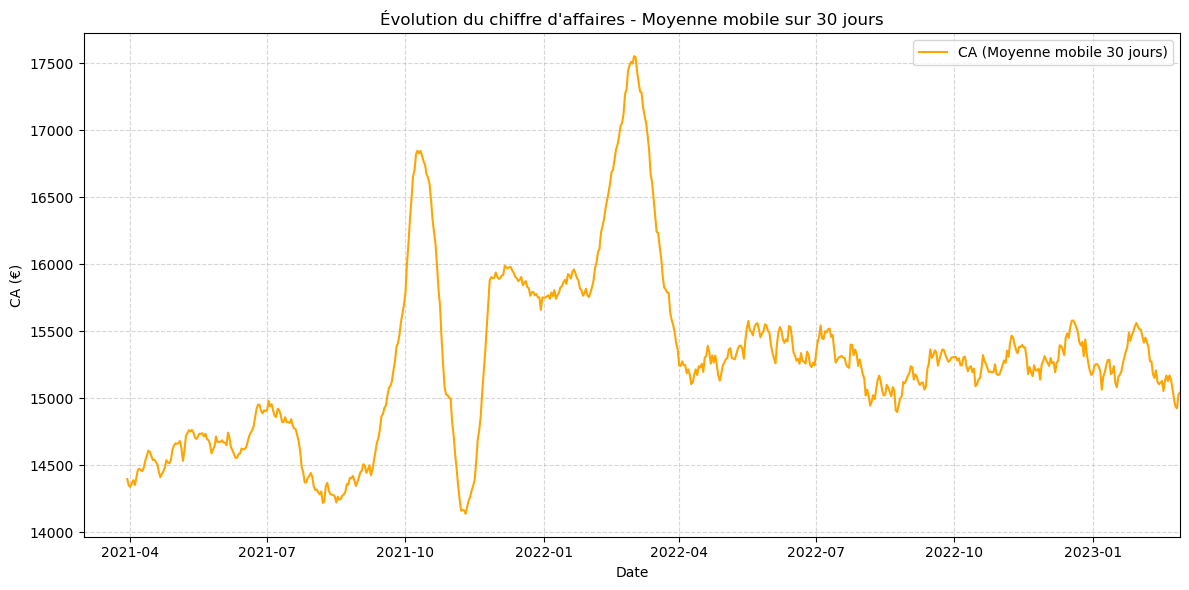

In [26]:
#Aperçu de la moyenne mobile mensuel pour voir si des disparités avec la moyenne mobile hebdomadaire existe

ca_journalier_mm30 = ca_journalier.rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(ca_journalier_mm30.index, ca_journalier_mm30.values, label='CA (Moyenne mobile 30 jours)', color='orange')
plt.title('Évolution du chiffre d\'affaires - Moyenne mobile sur 30 jours')
plt.xlabel('Date')
plt.ylabel('CA (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlim(p1_deb, p3_deb - pd.Timedelta(days=1))
plt.tight_layout()
plt.show()

In [27]:
#Calcul du coefficient de variation pour comparer la dispersion des différents indicateurs
std_ca_mm30 = ca_journalier_mm30.std()
cv_CA30 = round(ca_journalier_mm30.std() / ca_journalier_mm30.mean()*100,2)
std_ca_mm7 = ca_journalier_mm7.std()
cv_CA7 = round(ca_journalier_mm7.std() / ca_journalier_mm7.mean()*100,2)
print(f"Le coefficient de variation du CA moyen hebdomadaire est de {cv_CA7} %.")
print(f"Le coefficient de variation du CA moyen mensuel est de {cv_CA30} %.")

Le coefficient de variation du CA moyen hebdomadaire est de 5.88 %.
Le coefficient de variation du CA moyen mensuel est de 4.2 %.


<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">3.2 Nombre de clients</h1>
</div>

In [28]:
# Décompte globale du nombre de transactions
print("Le nombre de client_id distincts dans le fichier transactions est de {}".format(transactions['client_id'].nunique()))
print("Le nombre de client_id distincts dans le fichier customers est de {}".format(customers['client_id'].nunique()))
print("Le nombre de client_id distincts dans le fichier global sur la période 2021-2022 est de {}".format(df_merge_filtre.loc[mask_p1, 'client_id'].nunique()))
print("Le nombre de client_id distincts dans le fichier global sur la période 2022-2023 est de {}".format(df_merge_filtre.loc[mask_p2, 'client_id'].nunique()))

Le nombre de client_id distincts dans le fichier transactions est de 8600
Le nombre de client_id distincts dans le fichier customers est de 8621
Le nombre de client_id distincts dans le fichier global sur la période 2021-2022 est de 8596
Le nombre de client_id distincts dans le fichier global sur la période 2022-2023 est de 8520


In [29]:
#Compter le nombre de clients par mois
clients_par_mois = df_merge_filtre.groupby(df_merge['date'].dt.to_period('M'))['client_id'].nunique()
print(clients_par_mois.head(15))

date
2021-03    5672
2021-04    5670
2021-05    5640
2021-06    5655
2021-07    5668
2021-08    5638
2021-09    5689
2021-10    6186
2021-11    5871
2021-12    5863
2022-01    5805
2022-02    5725
2022-03    5831
2022-04    5691
2022-05    5839
Freq: M, Name: client_id, dtype: int64


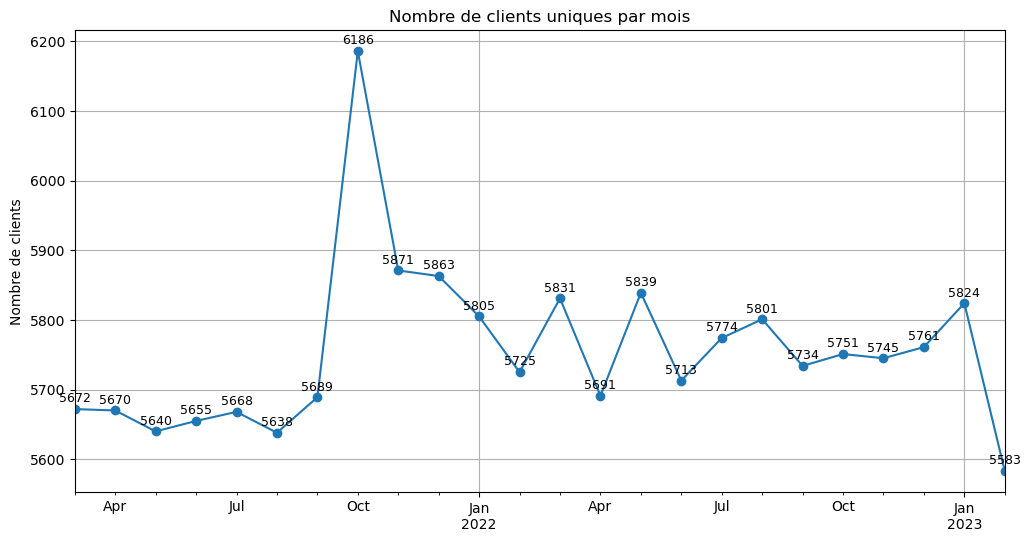

In [30]:
# Représentation graphique du nombre de clients par mois
ax = clients_par_mois.plot(kind='line', marker='o', figsize=(12,6))
plt.title("Nombre de clients uniques par mois")
plt.xlabel("")
plt.ylabel("Nombre de clients")
plt.grid(True)
# Affichage des valeurs pour chaque point
for x, y in zip(clients_par_mois.index, clients_par_mois.values):
    ax.annotate(
        str(y),
        (x, y),
        textcoords="offset points",
        xytext=(0, 5),
        ha='center',
        fontsize=9
    )

plt.show()

In [31]:
#Calcul du coefficient de variation pour comparer la dispersion des différents indicateurs
cv_nb_clients = round(clients_par_mois.std()/clients_par_mois.mean()*100,2)
print(f"Le coefficient de variation concernant le nombre de clients mensuels est de {cv_nb_clients} %.")

Le coefficient de variation concernant le nombre de clients mensuels est de 2.09 %.


<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">3.3 Nombre de transactions</h1>
</div>

In [32]:
# Décompte globale du nombre de transactions
print("Le nombre de transactions dans le fichier global est {}".format(df_merge_filtre['session_id'].nunique()))
print("Le nombre de transactions pour la période 2021-2022 est de {}".format(df_merge_filtre.loc[mask_p1, 'session_id'].nunique()))
print("Le nombre de transactions pour la période 2022-2023 est de {}".format(df_merge_filtre.loc[mask_p2, 'session_id'].nunique()))

Le nombre de transactions dans le fichier global est 322466
Le nombre de transactions pour la période 2021-2022 est de 161018
Le nombre de transactions pour la période 2022-2023 est de 161448


In [33]:
#Compter le nombre de transactions par mois
transactions_par_mois = df_merge_filtre.groupby(df_merge['date'].dt.to_period('M'))['session_id'].nunique()
print(transactions_par_mois.head(15))

date
2021-03    13285
2021-04    13014
2021-05    13165
2021-06    12929
2021-07    12685
2021-08    12696
2021-09    13848
2021-10    13995
2021-11    13612
2021-12    14478
2022-01    13999
2022-02    13357
2022-03    13845
2022-04    13129
2022-05    13950
Freq: M, Name: session_id, dtype: int64


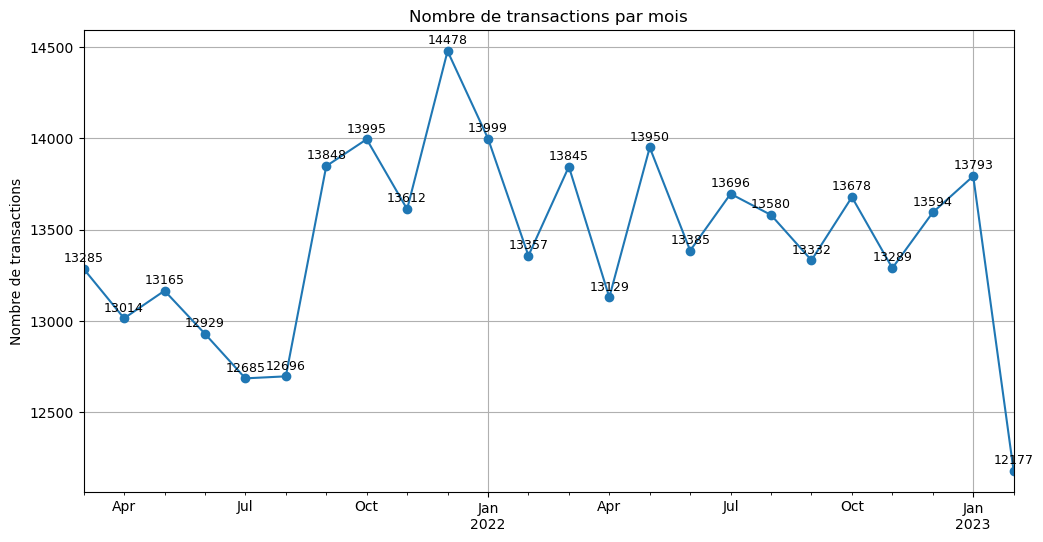

In [34]:
# Représentation graphique du nombre de transactions par mois
ax1 = transactions_par_mois.plot(kind='line', marker='o', figsize=(12,6))
plt.title("Nombre de transactions par mois")
plt.xlabel("")
plt.ylabel("Nombre de transactions")
plt.grid(True)
# Affichage des valeurs pour chaque point
for x, y in zip(transactions_par_mois.index, transactions_par_mois.values):
    ax1.annotate(
        str(y),
        (x, y),
        textcoords="offset points",
        xytext=(0, 5),
        ha='center',
        fontsize=9
    )

plt.show()

In [35]:
#Calcul du coefficient de variation pour comparer la dispersion des différents indicateurs
cv_nb_transactions = round(transactions_par_mois.std()/transactions_par_mois.mean()*100,2)
print(f"Le coefficient de variation concernant le nombre de transactions mensuelles est de {cv_nb_transactions} %.")

Le coefficient de variation concernant le nombre de transactions mensuelles est de 3.8 %.


<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">3.4 Nombre de produits</h1>
</div>

In [36]:
print(f"Au total, {df_merge_filtre['id_prod'].nunique()} références dans notre catalogue ont été vendus sur la totalité de la période.")
print(f"Pour l'année 2021-2022, {df_merge_filtre.loc[mask_p1, 'id_prod'].nunique()} références différentes ont été vendues.")
print(f"Pour l'année 2022-2023, {df_merge_filtre.loc[mask_p2, 'id_prod'].nunique()} références différentes ont été vendues.")

Au total, 3262 références dans notre catalogue ont été vendus sur la totalité de la période.
Pour l'année 2021-2022, 3262 références différentes ont été vendues.
Pour l'année 2022-2023, 3208 références différentes ont été vendues.


In [37]:
#Compter le nombre de produits vendus par mois
produits_par_mois = df_merge_filtre.groupby(df_merge['date'].dt.to_period('M'))['id_prod'].count()
print(produits_par_mois.head(15))

date
2021-03    26647
2021-04    26470
2021-05    26272
2021-06    25038
2021-07    23075
2021-08    23955
2021-09    30975
2021-10    28313
2021-11    26319
2021-12    30208
2022-01    27416
2022-02    27569
2022-03    27703
2022-04    25659
2022-05    27946
Freq: M, Name: id_prod, dtype: int64


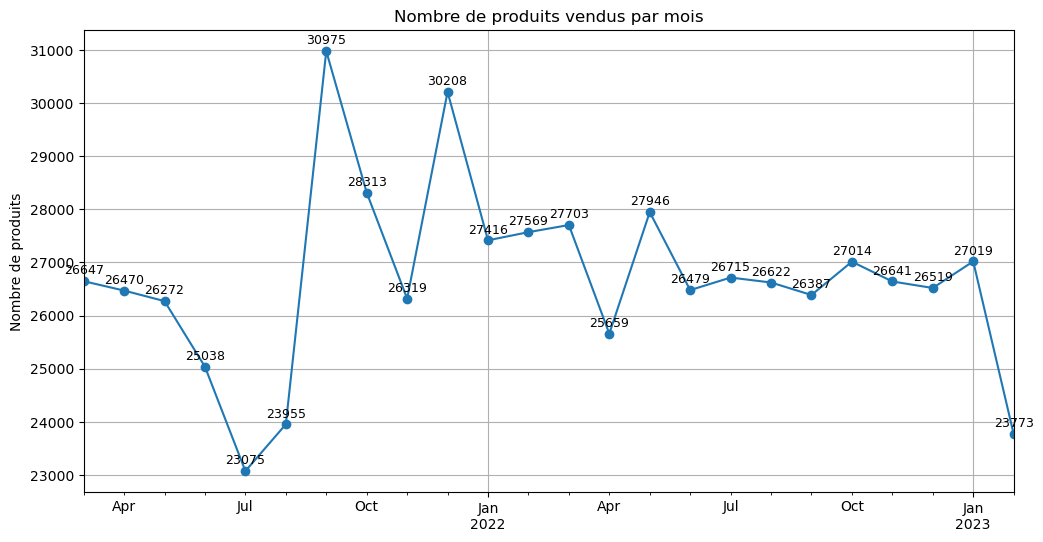

In [38]:
# Représentation graphique du nombre de produits vendus par mois
ax1 = produits_par_mois.plot(kind='line', marker='o', figsize=(12,6))
plt.title("Nombre de produits vendus par mois")
plt.xlabel("")
plt.ylabel("Nombre de produits")
plt.grid(True)
# Affichage des valeurs pour chaque point
for x, y in zip(produits_par_mois.index, produits_par_mois.values):
    ax1.annotate(
        str(y),
        (x, y),
        textcoords="offset points",
        xytext=(0, 5),
        ha='center',
        fontsize=9
    )

plt.show()

In [39]:
#Calcul du coefficient de variation pour comparer la dispersion des différents indicateurs
cv_nb_produits = round(produits_par_mois.std()/produits_par_mois.mean()*100,2)
print(f"Le coefficient de variation concernant le nombre de produits mensuels est de {cv_nb_produits} %.")

Le coefficient de variation concernant le nombre de produits mensuels est de 6.58 %.


<div style="display: flex; background-color: RGB(51,153,255);" >
<h1 style="margin: auto; padding: 30px; ">📊 Étape 4 - Analyse des références</h1>
</div>

<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">4.1 Top Produits</h1>
</div>

In [40]:
# Top 20 en nombre de ventes
produits_vendus = df_merge_filtre.groupby('id_prod').size().reset_index(name='nb_ventes')
top_produits_vendus = produits_vendus.nlargest(10, 'nb_ventes')
top_produits_vendus.head(10)

,id_prod,nb_ventes
2589,1_369,2205
2642,1_417,2123
2639,1_414,2114
2731,1_498,2042
2651,1_425,2026
2638,1_413,1935
2637,1_412,1915
2631,1_407,1883
2618,1_396,1875
2627,1_403,1874


In [41]:
# Top 20 en chiffre d'affaires
produits_ca = df_merge_filtre.groupby('id_prod')['price'].sum().reset_index(name='CA par article')
top_produits_ca = produits_ca.nlargest(10, 'CA par article')
top_produits_ca.head(10)

,id_prod,CA par article
3093,2_159,91097.76
3067,2_135,63470.80
3043,2_112,58785.90
3032,2_102,55650.74
2589,1_369,52897.95
2617,1_395,52182.00
3149,2_209,50742.75
2639,1_414,50376.62
2605,1_383,49746.84
3101,2_166,48308.40


<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">4.2 Flop Produits</h1>
</div>

In [42]:
# FLop 20 en nombre de produits vendus
flop_produits_vendus = produits_vendus.nsmallest(20, 'nb_ventes')
flop_produits_vendus.head(10)

,id_prod,nb_ventes
165,0_1151,1
209,0_1191,1
312,0_1284,1
416,0_1379,1
548,0_1498,1
588,0_1533,1
594,0_1539,1
664,0_1601,1
697,0_1633,1
751,0_1683,1


In [43]:
nb_produits_vendus_1 = (produits_vendus['nb_ventes'] == 1).sum()
print(nb_produits_vendus_1)

26


In [44]:
# Flop 20 en chiffre d'affaires
flop_produits_ca = produits_ca.nsmallest(10, 'CA par article')
flop_produits_ca.head(10)

,id_prod,CA par article
209,0_1191,0.99
594,0_1539,0.99
312,0_1284,1.38
799,0_1726,1.57
718,0_1653,1.98
664,0_1601,1.99
958,0_1871,1.99
1783,0_541,1.99
2077,0_807,1.99
801,0_1728,2.27


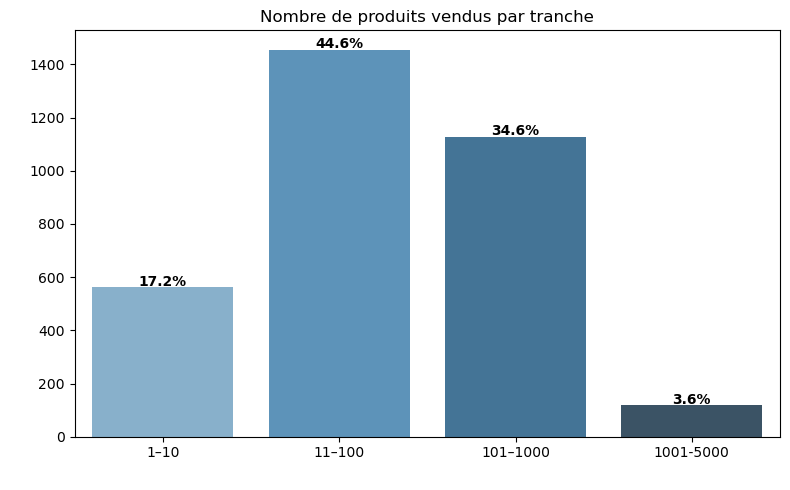

In [45]:
# Représentation graphique du nombre de ventes par tranche
bins = [0, 10, 100, 1000, 5000]  # bornes de tes classes
labels = ['1–10', '11–100', '101–1000', '1001-5000']

produits_vendus['tranche_ventes'] = pd.cut(
    produits_vendus['nb_ventes'],
    bins=bins,
    labels=labels,
    right=True,   # inclut la borne supérieure
    include_lowest=True
)

ventes_par_tranche = produits_vendus['tranche_ventes'].value_counts().sort_index()

total = ventes_par_tranche.sum()
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=ventes_par_tranche.index,
    y=ventes_par_tranche.values,
    hue=ventes_par_tranche.index,
    palette='Blues_d',
    legend=False
)

for i, v in enumerate(ventes_par_tranche.values):
    ax.text(i, v + 5, f"{(v/total*100):.1f}%", ha='center', fontweight='bold')

plt.title("Nombre de produits vendus par tranche")
plt.xlabel(" ")
plt.ylabel(" ")
plt.tight_layout()
plt.show()

<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">4.3 Ventes par catégories</h1>
</div>

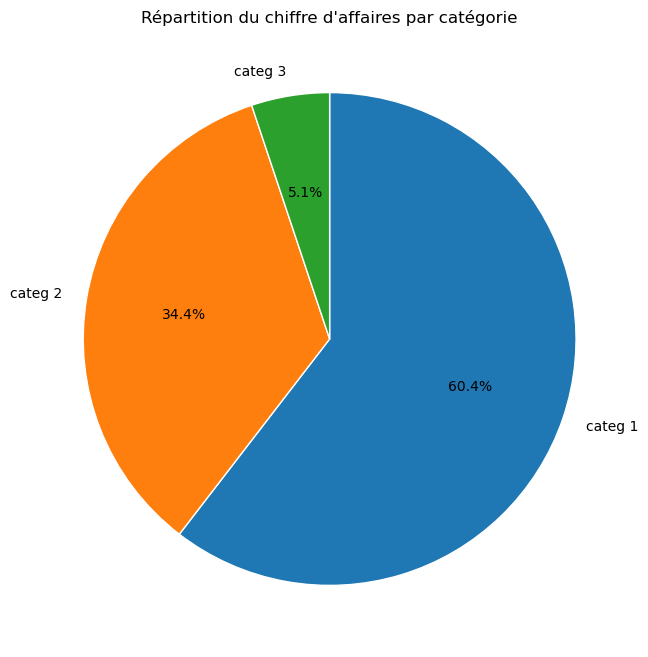

In [46]:
# Agrégation par catégorie
vente_par_categ = df_merge_filtre.groupby('categ').size().reset_index(name='nb_ventes')

# Création du pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    vente_par_categ['nb_ventes'],
    labels=vente_par_categ['categ'],
    autopct='%1.1f%%',      
    startangle=90,          
    counterclock=False,    
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Répartition du chiffre d'affaires par catégorie")
plt.show()

In [47]:
#CA par catégorie, par année
# Création de deux sous-ensembles
df_p1 = df_merge_filtre.loc[mask_p1].copy()
df_p2 = df_merge_filtre.loc[mask_p2].copy()

# Ajout d'une colonne 'période'
df_p1['période'] = '2021-2022'
df_p2['période'] = '2022-2023'

# Fusion des deux DataFrames
df_concat = pd.concat([df_p1, df_p2])

# Pivot pour avoir les catégories en colonnes et les périodes en lignes
pivot_ca = df_concat.pivot_table(
    values='price',
    index='période',
    columns='categ',
    aggfunc='sum'
)

# Ajout d'une ligne de total
pivot_ca['Total'] = pivot_ca.sum(axis=1)
display(pivot_ca)

categ,categ 1,categ 2,categ 3,Total
période,,,,
2021-2022,2078274.77,2272254.21,1216184.37,5566713.35
2022-2023,2040925.92,2247847.65,1287880.09,5576653.66


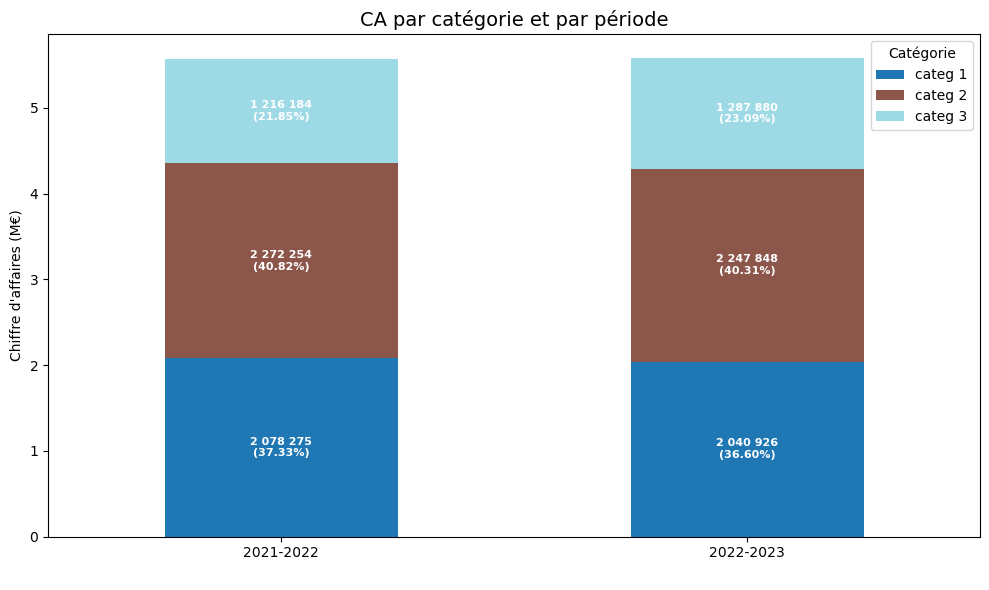

In [48]:
# Représentation du CA par catégorie et par période
# Sélection des colonnes catégories
categories = ['categ 1', 'categ 2', 'categ 3']

# Conversion en millions pour l'affichage graphique
pivot_ca_millions = pivot_ca[categories] / 1e6

# Calcul des pourcentages
pivot_ca_pct = pivot_ca_millions.div(pivot_ca_millions.sum(axis=1), axis=0) * 100

# Valeurs réelles
pivot_ca_values = pivot_ca[categories]

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))
pivot_ca_millions.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='tab20'
)

# Mise en forme
ax.set_title("CA par catégorie et par période", fontsize=14)
ax.set_xlabel(" ")
ax.set_ylabel("Chiffre d'affaires (M€)")
ax.set_xticklabels(pivot_ca.index, rotation=0)
ax.legend(title="Catégorie")

# Labels dans les barres (valeurs réelles + %)
for i, container in enumerate(ax.containers):
    values = pivot_ca_values.iloc[:, i]
    percents = pivot_ca_pct.iloc[:, i]
    labels = [f"{val:,.0f}\n({pct:.2f}%)".replace(",", " ")
              for val, pct in zip(values, percents)]
    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=8,
        color='white',
        weight='bold'
    )

plt.tight_layout()
plt.show()

<div style="display: flex; background-color: RGB(51,153,255);" >
<h1 style="margin: auto; padding: 30px; ">🔎 Étape 5 - Analyse des clients</h1>
</div>

<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">5.1 Analyse client et panier</h1>
</div>

In [49]:
#Base client
total_clients = df_merge_filtre['client_id'].nunique()
Nb_clients_2022 = df_merge_filtre.loc[mask_p1, 'client_id'].nunique()
Nb_clients_2023 = df_merge_filtre.loc[mask_p2, 'client_id'].nunique()
print(f"Nombre de clients uniques : {total_clients} au total, "
      f"{Nb_clients_2022} en 2021-2022, "
      f"{Nb_clients_2023} en 2022-2023.")

Nombre de clients uniques : 8596 au total, 8596 en 2021-2022, 8520 en 2022-2023.


In [50]:
#Panier Moyen
panier_par_session = df_merge_filtre.groupby('session_id')['price'].sum()
panier_moyen_global = panier_par_session.mean()
print(f"Le panier moyen global est de {panier_moyen_global:.2f} €")

Le panier moyen global est de 34.56 €


In [51]:
#Top 10 Panier
panier_clients = df_merge_filtre.groupby('session_id')['price'].sum().reset_index(name='CA par panier')
top_10_panier = panier_clients.nlargest(10, 'CA par panier')
top_10_panier.head(10)

,session_id,CA par panier
318136,s_95844,568.88
24237,s_123227,539.23
241164,s_335005,535.17
305006,s_83158,535.17
52440,s_150439,496.22
73171,s_170478,476.19
120465,s_216724,452.45
225687,s_319865,452.45
290761,s_69450,452.45
213745,s_308091,450.09


In [52]:
# Top 10 clients en CA
clients_CA_filtre = df_merge_filtre.groupby('client_id')['price'].sum().reset_index(name='CA par client').sort_values(by='CA par client', ascending = False)
clients_CA_filtre.head(10)

,client_id,CA par client
634,c_1570,5285.82
2512,c_3263,5276.87
1267,c_2140,5260.18
2107,c_2899,5214.05
7002,c_7319,5155.77
7711,c_7959,5135.75
470,c_1422,5131.36
7116,c_7421,5097.18
7787,c_8026,5082.58
1672,c_2505,5059.35


<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">5.2 Courbe de Lorenz</h1>
</div>

In [53]:
# Reprise de l'agrégation clients_CA et tri croissant par 'CA par client'
clients_CA_filtre = clients_CA_filtre.sort_values(by='CA par client', ascending=True).reset_index(drop=True)
#Calcul du CA total
CA_total = clients_CA_filtre['CA par client'].sum()
#Création de la colonne 'Part du CA total'
clients_CA_filtre['Part du CA total (%)'] = clients_CA_filtre['CA par client'] / CA_total * 100
#Création de la colonne 'Part cumulée'
clients_CA_filtre['Part cumulée (%)'] = clients_CA_filtre['Part du CA total (%)'].cumsum()

# Part cumulée des clients (axe des X)
clients_CA_filtre['Part clients'] = (
    (clients_CA_filtre.index + 1) / len(clients_CA_filtre)
)

# Part cumulée du CA (axe des Y)
clients_CA_filtre['Part CA cumulée'] = (
    clients_CA_filtre['CA par client'].cumsum() /
    clients_CA_filtre['CA par client'].sum()
)

clients_CA_filtre.head()

,client_id,CA par client,Part du CA total (%),Part cumulée (%),Part clients,Part CA cumulée
0,c_8351,6.31,0.000057,0.000057,0.000116,5.662561e-07
1,c_8140,8.30,0.000074,0.000131,0.000233,1.311094e-06
2,c_8114,9.98,0.000090,0.000221,0.000349,2.206694e-06
3,c_4648,11.20,0.000101,0.000321,0.000465,3.211776e-06
4,c_4478,13.36,0.000120,0.000441,0.000582,4.410696e-06


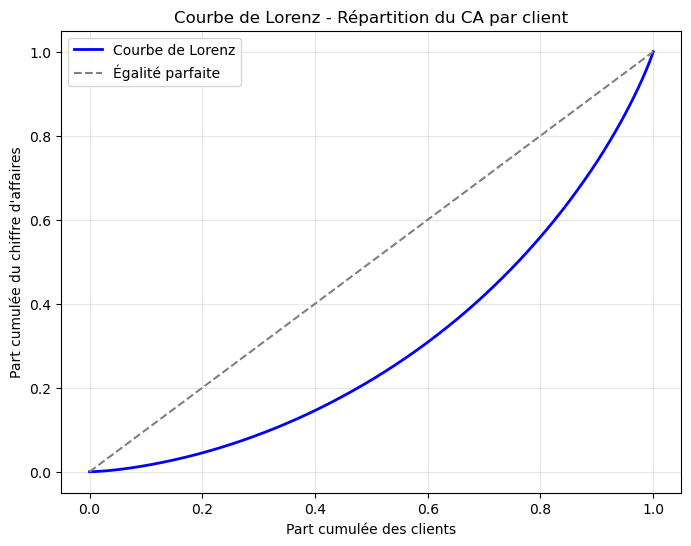

In [54]:
# Représentation graphique de la courbe de Lorenz
# Insertion de (0,0)
x = np.insert(clients_CA_filtre['Part clients'].values, 0, 0)
y = np.insert(clients_CA_filtre['Part CA cumulée'].values, 0, 0)

plt.figure(figsize=(8, 6))

# Courbe de Lorenz plus fine
plt.plot(x, y, label='Courbe de Lorenz', color='blue', linewidth=2)

# Ligne d'égalité parfaite
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Égalité parfaite')

plt.title("Courbe de Lorenz - Répartition du CA par client")
plt.xlabel("Part cumulée des clients")
plt.ylabel("Part cumulée du chiffre d'affaires")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
# Trouver le premier indice où y >= 0.8
indice_80 = np.argmax(y >= 0.8)

# Part correspondante de clients
part_clients_80 = x[indice_80] * 100

print(f"Pour atteindre 80 % du CA, il faut environ {part_clients_80:.2f} % des clients.")

Pour atteindre 80 % du CA, il faut environ 92.87 % des clients.


<div style="display: flex; background-color: RGB(51,153,255);" >
<h1 style="margin: auto; padding: 30px; ">🔎 Etape 6 - Recherche de correlations</h1>
</div>

<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">6.1 Lien entre genre d'un client et catégorie de livres</h1>
</div>

<div style="display: flex; background-color: RGB(204,209,255);" >
<h1 style="margin: auto; padding: 30px; ">6.1.1 Test du lien au niveau client</h1>
</div>

In [56]:
#Création d'une copie
df = df_merge_filtre.copy()

# Renommage de la colonne "categ" pour faciliter la manipulation
df["category"] = (
    df["categ"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype("Int64")
)

# Filtrer les lignes valides
df = df[df["sex"].isin(["f", "m"]) & df["category"].notna()].copy()

In [57]:
# Agregation par client, sexe et catégorie
df_client_categ = (
    df.groupby(["client_id", "sex", "category"])
    .size()
    .reset_index(name="nb_achats")
)

# Identifier la catégorie dominante pour chaque client
df_top_categ = (
    df_client_categ
    .loc[df_client_categ.groupby("client_id")["nb_achats"].idxmax()]
    .reset_index(drop=True)
)
df_client_categ.head()

,client_id,sex,category,nb_achats
0,c_1,m,1,30
1,c_1,m,2,12
2,c_1,m,3,1
3,c_10,m,1,20
4,c_10,m,2,34


In [58]:
#Création de la table de contingence pour le calcul du Khi²
ct = pd.crosstab(df_top_categ["sex"], df_top_categ["category"])
print(ct)

category     1     2    3
sex                      
f         2370  1608  500
m         2256  1385  477


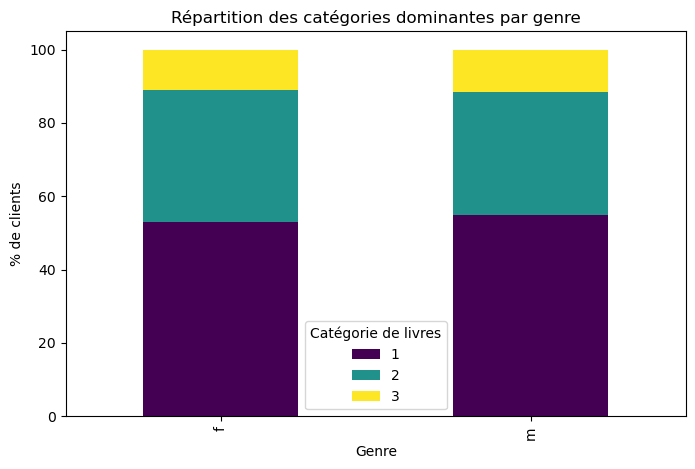

In [59]:
#Représentation graphique de la répartition des ventes par catégorie et par genre
ct_norm = ct.div(ct.sum(axis=1), axis=0) * 100  # pourcentages par ligne

ct_norm.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8,5))
plt.title("Répartition des catégories dominantes par genre")
plt.ylabel("% de clients")
plt.xlabel("Genre")
plt.legend(title="Catégorie de livres")
plt.show()

In [60]:
#Calcul du Khi deux
chi2, p, dof, expected = chi2_contingency(ct)

print(f"Chi² = {chi2:.2f}, ddl = {dof}, p-value = {p:.4f}")

Chi² = 4.90, ddl = 2, p-value = 0.0864


In [61]:
print("La valeur du Khi² de 4,90 avec 2 degrés de liberté et une p-value de 0,0864 signifie qu’il n’y a pas de lien statistiquement significatif entre le genre des clients et la catégorie de livres achetés au seuil classique de 5%.\n" "Ici, la p-value obtenue (0,0864) est supérieure à ce seuil : on ne rejette pas l’hypothèse d'indépendance entre le genre et l'achat de certaines catégories de livres.")

La valeur du Khi² de 4,90 avec 2 degrés de liberté et une p-value de 0,0864 signifie qu’il n’y a pas de lien statistiquement significatif entre le genre des clients et la catégorie de livres achetés au seuil classique de 5%.
Ici, la p-value obtenue (0,0864) est supérieure à ce seuil : on ne rejette pas l’hypothèse d'indépendance entre le genre et l'achat de certaines catégories de livres.


<div style="display: flex; background-color: RGB(204,209,255);" >
<h1 style="margin: auto; padding: 30px; ">6.1.2 Test du lien au niveau transaction</h1>
</div>

Table de contingence :
category       1       2      3
sex                            
f         200793  115721  16980
m         186488  104884  15868

Test χ² d'indépendance
χ² = 22.669, ddl = 2, p-value = 1.196e-05


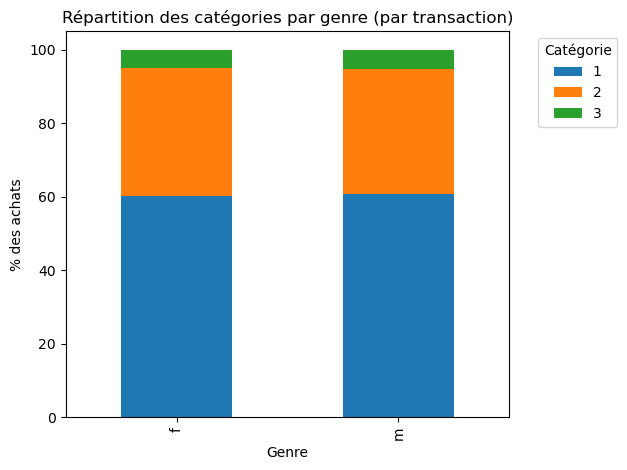

In [62]:
# Je teste le calcul du khi deux sur un df orienté transactions pour voir si des différences notables existent et pour déterminer quelle est 
#la meilleure approche

df_merge_filtre = df_merge_filtre[df_merge_filtre['price'] > 0].copy()

# 1) Nettoyage / préparation
# Exemple: extraire un entier de "categ 1" → 1
df_merge_filtre["category"] = (
    df_merge_filtre["categ"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype("Int64")
)

# Garde uniquement f/m et categorie non nulle
df_clean = df_merge_filtre[df_merge_filtre["sex"].isin(["f","m"]) & df_merge_filtre["category"].notna()].copy()

# 2) Table de contingence
ct = pd.crosstab(df_clean["sex"], df_clean["category"])

# 3) Test du chi-deux
chi2, p, dof, expected = chi2_contingency(ct)

min_dim = min(ct.shape) - 1

print("Table de contingence :")
print(ct)
print("\nTest χ² d'indépendance")
print(f"χ² = {chi2:.3f}, ddl = {dof}, p-value = {p:.4g}")

# 5) Visualisation: % par genre
prop = ct.div(ct.sum(axis=1), axis=0) * 100
ax = prop.plot(kind="bar", stacked=True)
ax.set_ylabel("% des achats")
ax.set_xlabel("Genre")
ax.set_title("Répartition des catégories par genre (par transaction)")
plt.legend(title="Catégorie", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [63]:
print("La valeur χ2=22.67 avec 2 degrés de liberté et une p-value de 0,00001196 signifie qu’il n’y a pas de lien statistiquement significatif entre l’âge des clients et la catégorie de livres achetés au seuil classique de 5%. Ici, la p-value obtenue est encore  inférieure à ce seuil : on ne rejette pas l’hypothèse nulle. L'hypothèse qu'il n'y a pas de lien est encore plus forte. Même en considérant un seuil de 0.01 (moins de 1% de risque d'erreur).")

      

La valeur χ2=22.67 avec 2 degrés de liberté et une p-value de 0,00001196 signifie qu’il n’y a pas de lien statistiquement significatif entre l’âge des clients et la catégorie de livres achetés au seuil classique de 5%. Ici, la p-value obtenue est encore  inférieure à ce seuil : on ne rejette pas l’hypothèse nulle. L'hypothèse qu'il n'y a pas de lien est encore plus forte. Même en considérant un seuil de 0.01 (moins de 1% de risque d'erreur).


<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">6.2 Corrélation entre l'âge des clients et le montant total des achats</h1>
</div>

In [64]:
#Agrégation par client et par âge et calcul des trois agrégats pour les corrélations à venir
df_client = (df_merge_filtre.groupby(["client_id", "age"])
               .agg(total_depenses=("price", "sum"),
                    panier_moyen=("price", "mean"),
                    freq_achats=("price", "count"))
               .reset_index())

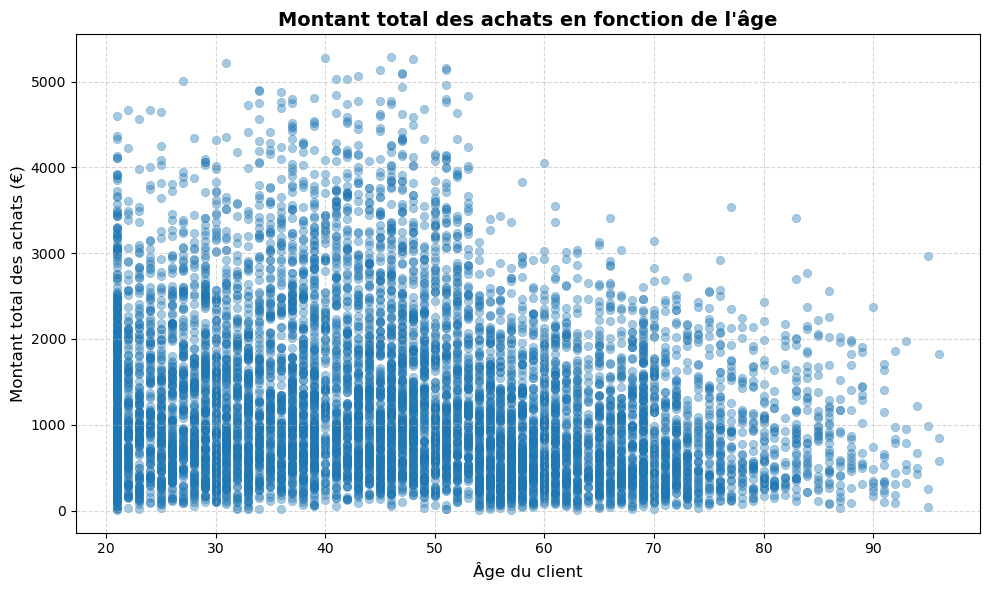

In [65]:
#Représentation graphique pour observer la répartition
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_client,
    x="age",
    y="total_depenses",
    alpha=0.4,              # transparence pour éviter les zones saturées
    edgecolor=None,         # évite le contour noir sur chaque point
)
plt.title("Montant total des achats en fonction de l'âge", fontsize=14, fontweight="bold")
plt.xlabel("Âge du client", fontsize=12)
plt.ylabel("Montant total des achats (€)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

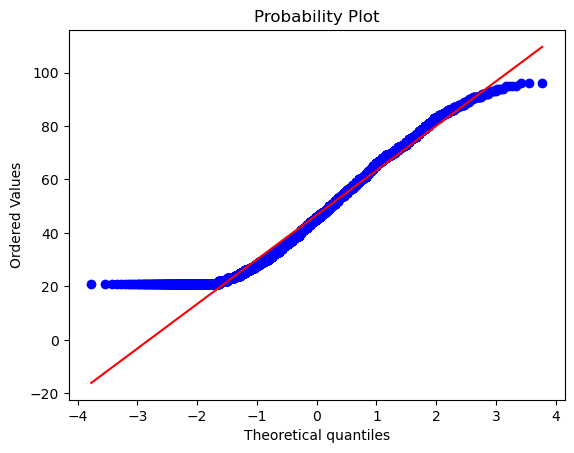

Les données ne collent pas complètement à la droite représentant une distribution normal parfaite, il y a une légère assymétrie


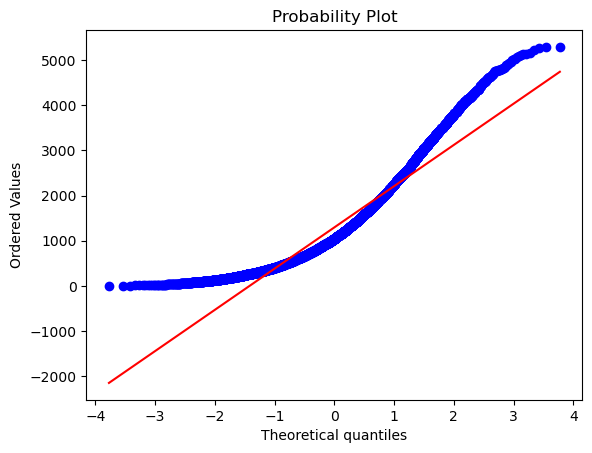

Les données s'écartent largement de la droite, la distribution n'est clairement pas de type normal


In [66]:
# Tracé de deux QQplot pour vérifier visuellement si nous avos affaires à des distributions de type normal
stats.probplot(df_client['age'], dist="norm", plot=plt)
plt.show()
print("Les données ne collent pas complètement à la droite représentant une distribution normal parfaite, il y a une légère assymétrie")
stats.probplot(df_client['total_depenses'], dist="norm", plot=plt)
plt.show()
print("Les données s'écartent largement de la droite, la distribution n'est clairement pas de type normal")

In [67]:
# Test de normalité de D’Agostino–Pearson sur total_depenses et age pour confirmer l'impression visuelle
stat, p = normaltest(df_client['total_depenses'])
stat, p = normaltest(df_client['total_depenses'])
print(f"Test de D’Agostino–Pearson sur total_depenses :")
print(f"  Statistique = {stat:.3f}")
print(f"  p-value = {p:.4g}")
print("La p-value est inférieur à 0.05, le montant total des achats ne suit pas une distribution normale ❌")
print("")
print(f"Test de D’Agostino–Pearson sur l'âge :")
print(f"  Statistique = {stat:.3f}")
print(f"  p-value = {p:.3e}")
print("La p-value est inférieur à 0.05, l'âge ne suit pas une distribution normale ❌\n")
print("Si une seule des deux variables ne suit pas la distribution normale, il faut opter pour un test non paramétrique pour tester la corrélation, ce sera le     test de Spearman")

Test de D’Agostino–Pearson sur total_depenses :
  Statistique = 1455.248
  p-value = 0
La p-value est inférieur à 0.05, le montant total des achats ne suit pas une distribution normale ❌

Test de D’Agostino–Pearson sur l'âge :
  Statistique = 1455.248
  p-value = 0.000e+00
La p-value est inférieur à 0.05, l'âge ne suit pas une distribution normale ❌

Si une seule des deux variables ne suit pas la distribution normale, il faut opter pour un test non paramétrique pour tester la corrélation, ce sera le     test de Spearman


In [68]:
# Calcul du coefficient de corrélation de Spearman
spearman_corr, _ = spearmanr(df_client['age'], df_client['total_depenses'])
print(f"Corrélation de Spearman : {spearman_corr:.3f}")
print("La corrélation n'est pas significative au sens statistique, la valeur du est ici faible et négative. Ce qui signifie que quand l’âge augmente, les dépenses totales ont légèrement tendance \nà être moins élevées.")

Corrélation de Spearman : -0.185
La corrélation n'est pas significative au sens statistique, la valeur du est ici faible et négative. Ce qui signifie que quand l’âge augmente, les dépenses totales ont légèrement tendance 
à être moins élevées.


<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">6.3 Corrélation entre l'âge des clients et la fréquence d’achat</h1>
</div>

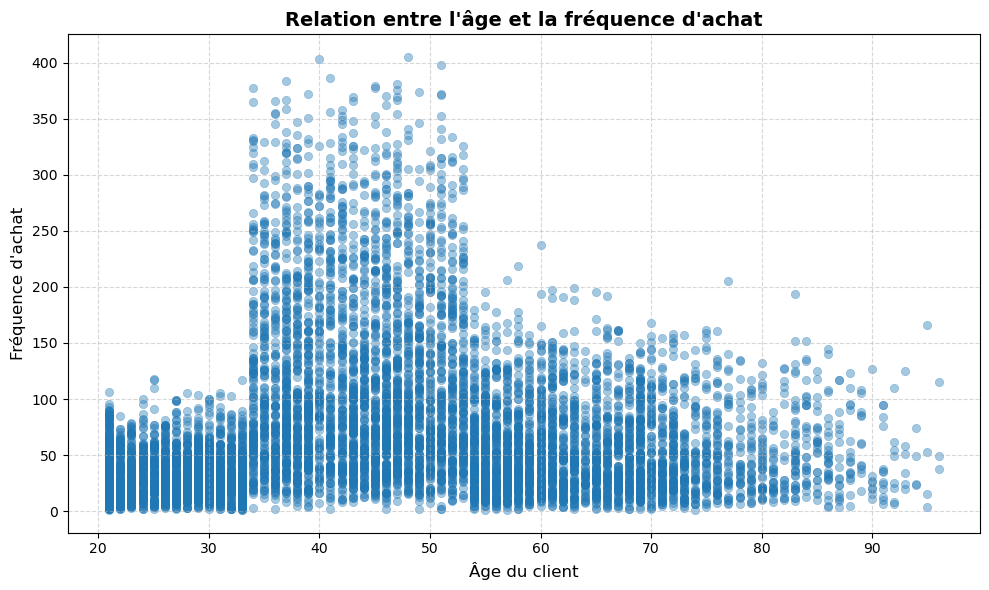

In [69]:
#Représentation graphique pour observer la répartition
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_client,
    x="age",
    y="freq_achats",
    alpha=0.4,         # transparence pour éviter la sursaturation
    edgecolor=None
)

plt.title("Relation entre l'âge et la fréquence d'achat", fontsize=14, fontweight="bold")
plt.xlabel("Âge du client", fontsize=12)
plt.ylabel("Fréquence d'achat", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

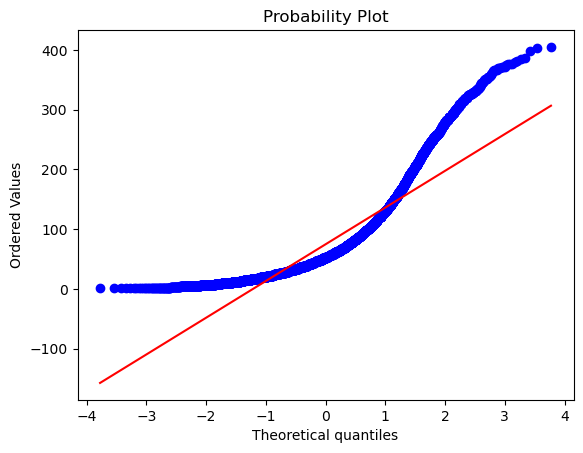

Les données s'écartent très largement de la droite, la distribution n'est clairement pas de type normal


In [70]:
# Tracé d'un QQplot pour vérifier visuellement si nous avons affaire à une distribution de type normale
stats.probplot(df_client['freq_achats'], dist="norm", plot=plt)
plt.show()
print("Les données s'écartent très largement de la droite, la distribution n'est clairement pas de type normal")

In [71]:
# Test de normalité de D’Agostino–Pearson sur freq achats pour confirmer l'impression visuelle
stat, p = normaltest(df_client['freq_achats'])
stat, p = normaltest(df_client['freq_achats'])
print(f"Test de D’Agostino–Pearson sur total_depenses :")
print(f"  Statistique = {stat:.3f}")
print(f"  p-value = {p:.4f}")
print("La p-value est inférieur à 0.05, le montant total des achats ne suit pas une distribution normale ❌")
print("Il faut là aussi opter pour le test de Spearman étant donné que nos deux variables ne suivent pas une distribution de type normale")

Test de D’Agostino–Pearson sur total_depenses :
  Statistique = 2822.721
  p-value = 0.0000
La p-value est inférieur à 0.05, le montant total des achats ne suit pas une distribution normale ❌
Il faut là aussi opter pour le test de Spearman étant donné que nos deux variables ne suivent pas une distribution de type normale


In [72]:
# Calcul du coefficient de corrélation de Spearman
spearman_corr, _ = spearmanr(df_client['age'], df_client['freq_achats'])
print(f"Corrélation de Spearman : {spearman_corr:.3f}")
print("La corrélation n'est pas significative d'un point de vue statistique, le coefficient est positif et très faible, l'âge explique peu la fréquence d'achats.")

Corrélation de Spearman : 0.128
La corrélation n'est pas significative d'un point de vue statistique, le coefficient est positif et très faible, l'âge explique peu la fréquence d'achats.


<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">6.4 Corrélation entre l'âge des clients et la taille du panier moyen</h1>
</div>

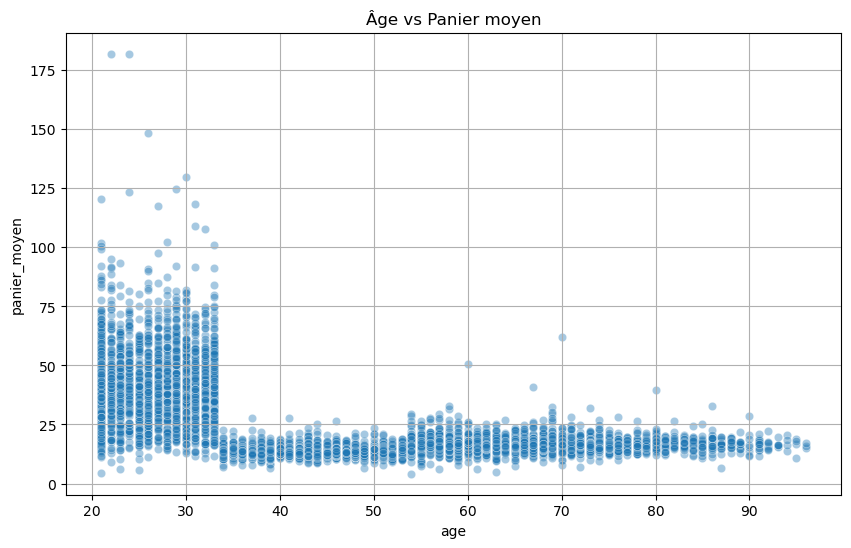

In [73]:
#Représentation graphique pour observer la répartition
plt.figure(figsize=(10,6))
plt.title("Âge vs Panier moyen")
plt.grid(True)
sns.scatterplot(data=df_client, x='age', y='panier_moyen', alpha=0.4)
plt.show()

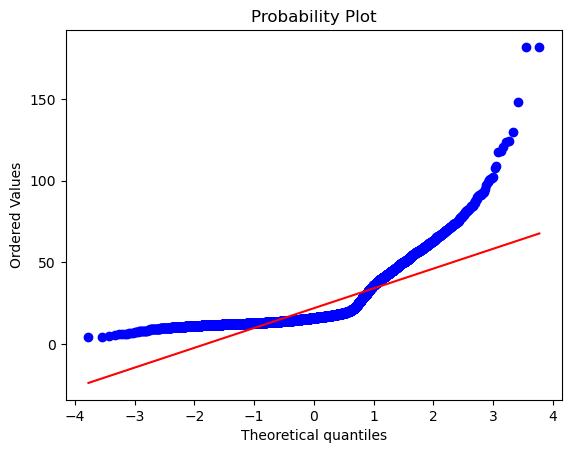

Les données s'écartent très largement de la droite, la distribution n'est clairement pas de type normal


In [74]:
# Tracé d'un QQplot pour vérifier visuellement si nous avons affaire à une distribution de type normale
stats.probplot(df_client['panier_moyen'], dist="norm", plot=plt)
plt.show()
print("Les données s'écartent très largement de la droite, la distribution n'est clairement pas de type normal")

In [75]:
# Test de normalité de D’Agostino–Pearson sur panier moyen pour confirmer l'impression visuelle
stat, p = normaltest(df_client['panier_moyen'])
stat, p = normaltest(df_client['panier_moyen'])
print(f"Test de D’Agostino–Pearson sur total_depenses :")
print(f"  Statistique = {stat:.3f}")
print(f"  p-value = {p:.4f}")
print("La p-value est inférieur à 0.05, le montant total des achats ne suit pas une distribution normale ❌")
print("Il faut là aussi opter pour le test de Spearman étant donné que nos deux variables ne suivent pas une distribution de type normale")

Test de D’Agostino–Pearson sur total_depenses :
  Statistique = 4558.283
  p-value = 0.0000
La p-value est inférieur à 0.05, le montant total des achats ne suit pas une distribution normale ❌
Il faut là aussi opter pour le test de Spearman étant donné que nos deux variables ne suivent pas une distribution de type normale


In [76]:
# Calcul du coefficient de corrélation de Spearman
spearman_corr, _ = spearmanr(df_client['age'], df_client['panier_moyen'])
print(f"Corrélation de Spearman : {spearman_corr:.3f}")
print("La corrélation est négative et faible. La tendance est que plus les clients sont âgés, plus leur panier moyen diminue, mais le lien n'est pas très fort, il peut y avoir d'autres explications à l'évolution du panier moyen.")

Corrélation de Spearman : -0.326
La corrélation est négative et faible. La tendance est que plus les clients sont âgés, plus leur panier moyen diminue, mais le lien n'est pas très fort, il peut y avoir d'autres explications à l'évolution du panier moyen.


<div style="display: flex; background-color: RGB(204,229,255);" >
<h1 style="margin: auto; padding: 30px; ">6.5 Lien entre l'âge des clients et la catégorie de produits</h1>
</div>

In [77]:
#Agrégation par client et par catégorie
top_cat = (
    df_merge_filtre
    .groupby(["client_id", "categ"])
    .size()
    .reset_index(name="nb_achats")
)

# Tri pour garder la catégorie la plus fréquente par client
top_cat = top_cat.sort_values(["client_id", "nb_achats"], ascending=[True, False])
top_cat = top_cat.drop_duplicates("client_id")

# Renommer pour plus de clarté
top_cat.rename(columns={"categ": "categ_client"}, inplace=True)

In [78]:
top_cat.head()

,client_id,categ_client,nb_achats
0,c_1,categ 1,30
4,c_10,categ 2,34
7,c_100,categ 2,5
10,c_1000,categ 2,83
11,c_1001,categ 1,70


In [79]:
#Fusion du df client avec le nouveau df top cat
df_client = df_client.merge(
    top_cat[["client_id", "categ_client"]],
    on="client_id",
    how="left"
)

In [80]:
# Test de la normalité de la distribution
# Méthode D’Agostino–Pearson (plus adapté aux grands échantillons)
for cat in df_client["categ_client"].unique():
    ages = df_client.loc[df_client["categ_client"] == cat, "age"].dropna()
    if len(ages) > 7:  # normaltest nécessite n > 7
        stat, p = normaltest(ages)
        print(f"Catégorie {cat} : p-value D’Agostino–Pearson = {p:.4e}")

Catégorie categ 1 : p-value D’Agostino–Pearson = 1.5916e-103
Catégorie categ 2 : p-value D’Agostino–Pearson = 1.0519e-268
Catégorie categ 3 : p-value D’Agostino–Pearson = 5.0391e-64


In [81]:
# Test de la normalité de la distribution
# Méthode Shapiro (pour confirmer/infirmer l'autre méthode))
for cat in df_client["categ_client"].unique():
    ages = df_client.loc[df_client["categ_client"] == cat, "age"].dropna()
    n = len(ages)
    if n >= 3:
        # On retient un échantillon pour le calcul car il y a sinon trop de valeurs
        sample = ages.sample(min(n, 5000), random_state=42)
        stat, p = shapiro(sample)
        print(f"Catégorie {cat} : n={n}, p-value Shapiro = {p:.4f}")

Catégorie categ 1 : n=4626, p-value Shapiro = 0.0000
Catégorie categ 2 : n=2993, p-value Shapiro = 0.0000
Catégorie categ 3 : n=977, p-value Shapiro = 0.0000


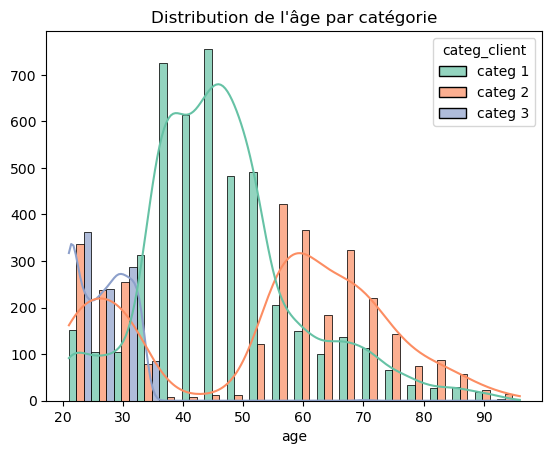

In [82]:
#Représentation graphique de la distribution des clients par âge et par catégorie
sns.histplot(
    data=df_client,
    x="age",
    hue="categ_client",
    kde=True,
    multiple="dodge",
    bins=20,  # ajuste selon ta distribution
    palette="Set2",
    alpha=0.7,
    edgecolor="black"
)
plt.ylabel('')
plt.title("Distribution de l'âge par catégorie")
plt.show()

In [83]:
print("Au regard de la représentation graphique, il apparaît que la distribution n'est pas de type normal pour l'ensemble des groupes, seule la catégorie 1 s'en rapproche, un test non-paramétrique doit donc donc être envisagé.")

Au regard de la représentation graphique, il apparaît que la distribution n'est pas de type normal pour l'ensemble des groupes, seule la catégorie 1 s'en rapproche, un test non-paramétrique doit donc donc être envisagé.


In [84]:
# Groupes d'âges par catégorie
groupes = [
    df_client.loc[df_client["categ_client"] == cat, "age"].dropna()
    for cat in df_client["categ_client"].unique()
]

In [85]:
# Test d'association, puisque la distribution n'est pas de type normal, je retiens la méthode de Kruskal-Wallis
h_stat, p_kw = kruskal(*groupes)
print(f"Kruskal–Wallis : H = {h_stat:.3f}, p-value = {p_kw:.3e}")
print("On rejette ici l'hypothèse selon laquelle les médianes des groupes sont égales.\n" "La très faible p-value nous indique qu'il existe une relation significative entre la catégorie de produit et l’âge des clients.\n" "Autrement dit, les médianes des groupes différents, un groupe au moins diffère. Visuellement, les acheteurs de la catégorie 3 se démarquent nettement.")

Kruskal–Wallis : H = 2003.668, p-value = 0.000e+00
On rejette ici l'hypothèse selon laquelle les médianes des groupes sont égales.
La très faible p-value nous indique qu'il existe une relation significative entre la catégorie de produit et l’âge des clients.
Autrement dit, les médianes des groupes différents, un groupe au moins diffère. Visuellement, les acheteurs de la catégorie 3 se démarquent nettement.
